In [75]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


# Alisha Khan
## Date: **13-09-2026**

In [76]:
# Data manipulation 
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries imported successfully!') 

Libraries imported successfully!


In [77]:
# Load data (Kaggle path)
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')
# First look
print('Dataset shape:', df.shape)
print() 
df.head() 

Dataset shape: (7043, 21)



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Dataset Overview 

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [79]:
df.describe() 

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [80]:
print('Missing Values:')
missing = df.isnull().sum()
print(missing[missing > 0]) 
# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce') 

Missing Values:
Series([], dtype: int64)


In [81]:
print('Churn Distribution:')
print(df['Churn'].value_counts()) 
print()
print('Churn Percentage:')
print(df['Churn'].value_counts(normalize=True) * 100) 

Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


Key Findings: Dataset has X customers. Churn rate is Y%. Z missing values in TotalCharges. Features include demographics, services, and account info. 

 ## 2. Numerical Features Analysis 

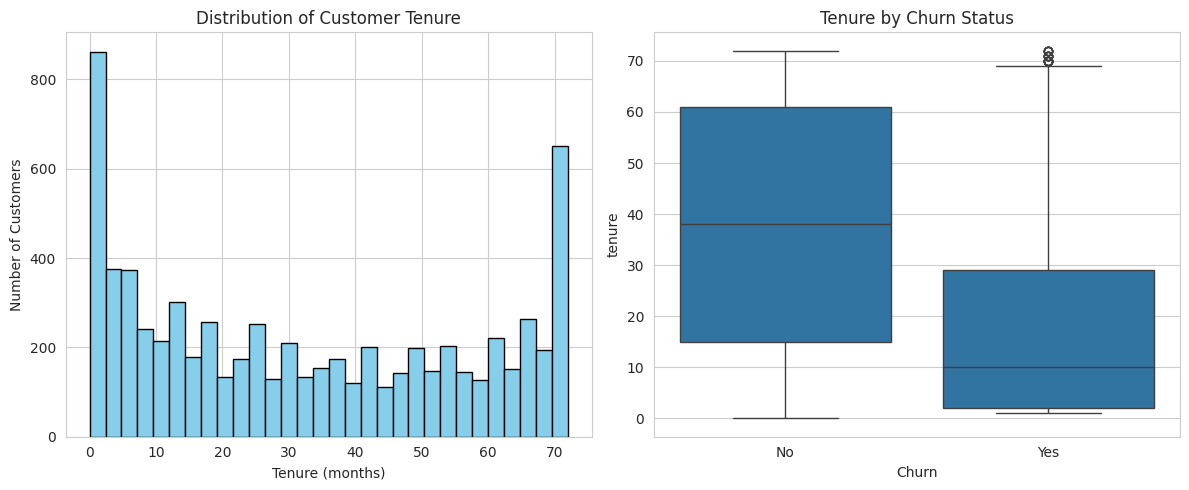

In [82]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['tenure'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Tenure (months)') 
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Tenure') 
plt.subplot(1, 2, 2)
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure by Churn Status')
plt.tight_layout()
plt.show() 

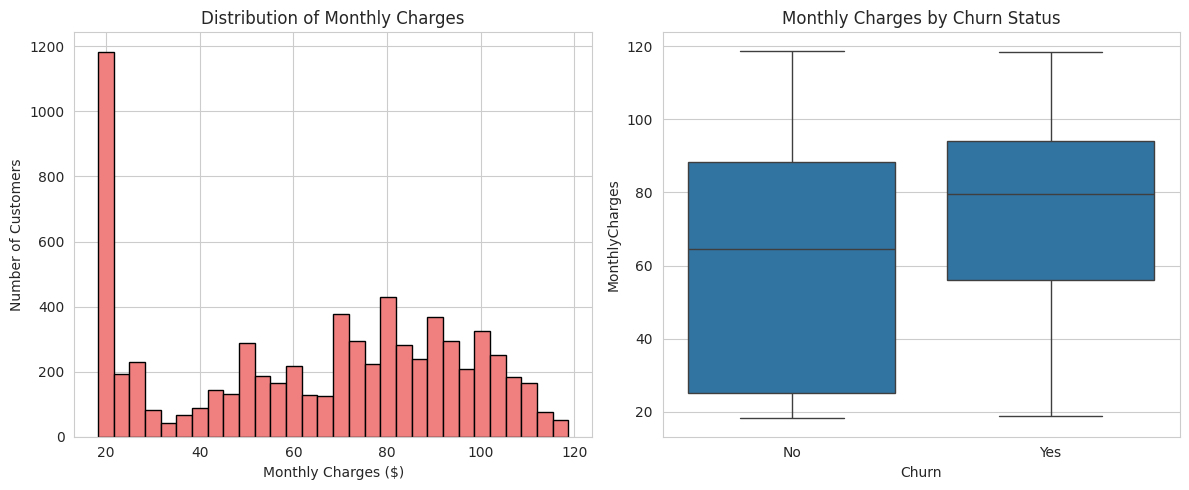

In [83]:
plt.figure(figsize=(12, 5)) 
plt.subplot(1, 2, 1)
plt.hist(df['MonthlyCharges'], bins=30, color='lightcoral', edgecolor='black') 
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Monthly Charges') 
plt.subplot(1, 2, 2) 
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges by Churn Status')
plt.tight_layout()
plt.show() 

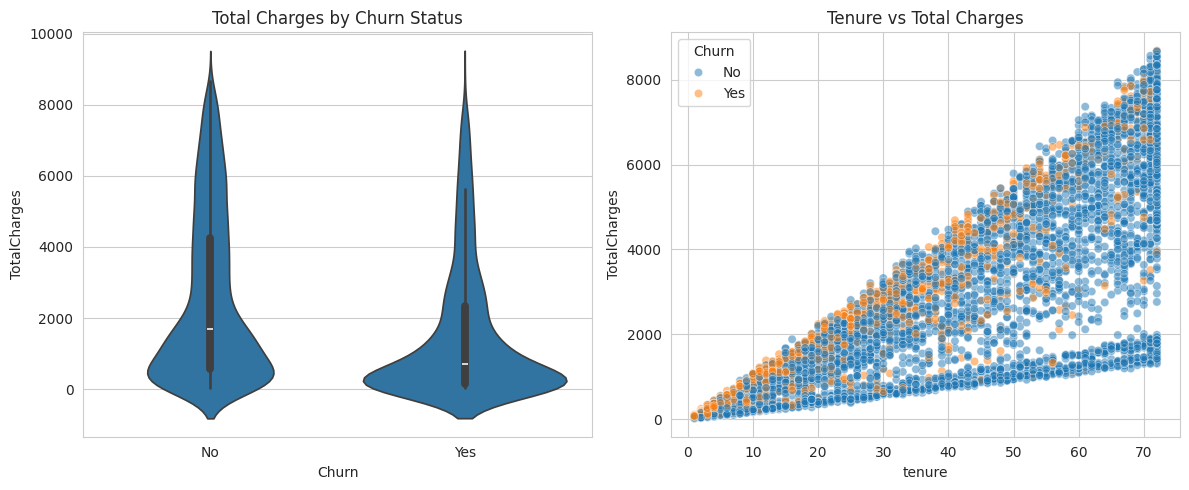

In [84]:
df_clean = df[df['TotalCharges'].notna()] 
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.violinplot(x='Churn', y='TotalCharges', data=df_clean) 
plt.title('Total Charges by Churn Status') 
plt.subplot(1, 2, 2) 
sns.scatterplot(x='tenure', y='TotalCharges', hue='Churn', data=df_clean, alpha=0.5)
plt.title('Tenure vs Total Charges') 
plt.tight_layout()
plt.show()

 ## 3. Categorical Features Analysis 

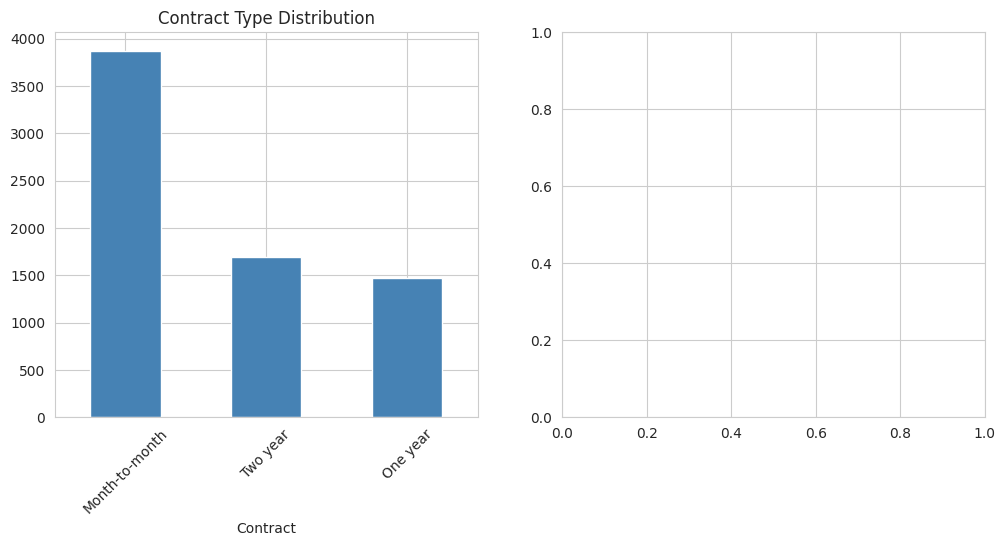

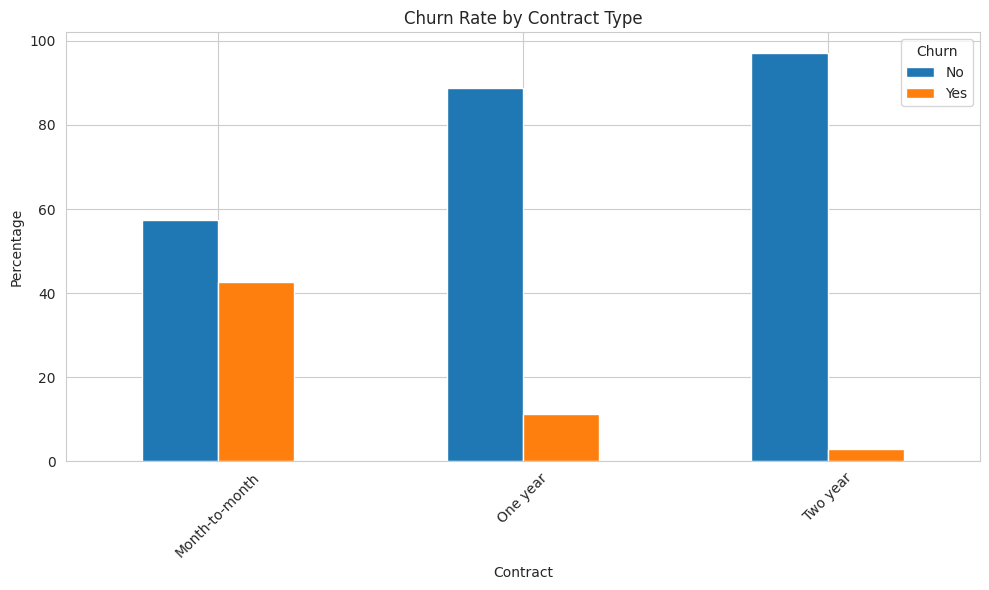

In [85]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) 
df['Contract'].value_counts().plot(kind='bar', color='steelblue') 
plt.title('Contract Type Distribution')
plt.xticks(rotation=45) 
plt.subplot(1, 2, 2)
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100 
contract_churn.plot(kind='bar', stacked=False) 
plt.title('Churn Rate by Contract Type') 
plt.ylabel('Percentage') 
plt.xticks(rotation=45)
plt.tight_layout()
plt.show() 

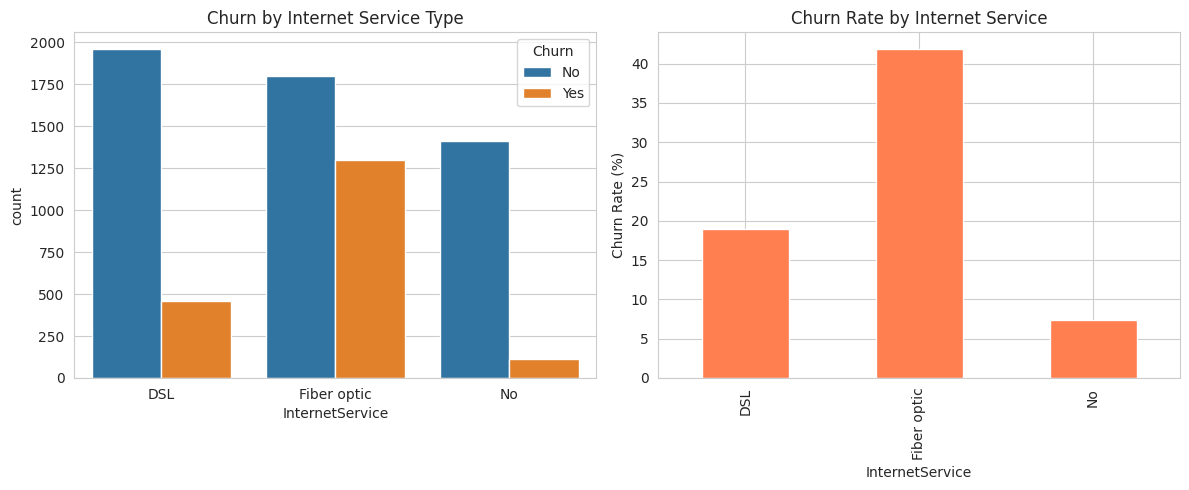

In [86]:
plt.figure(figsize=(12, 5)) 
plt.subplot(1, 2, 1)
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service Type') 
plt.subplot(1, 2, 2) 
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
internet_churn['Yes'].plot(kind='bar', color='coral')
plt.title('Churn Rate by Internet Service')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.show() 

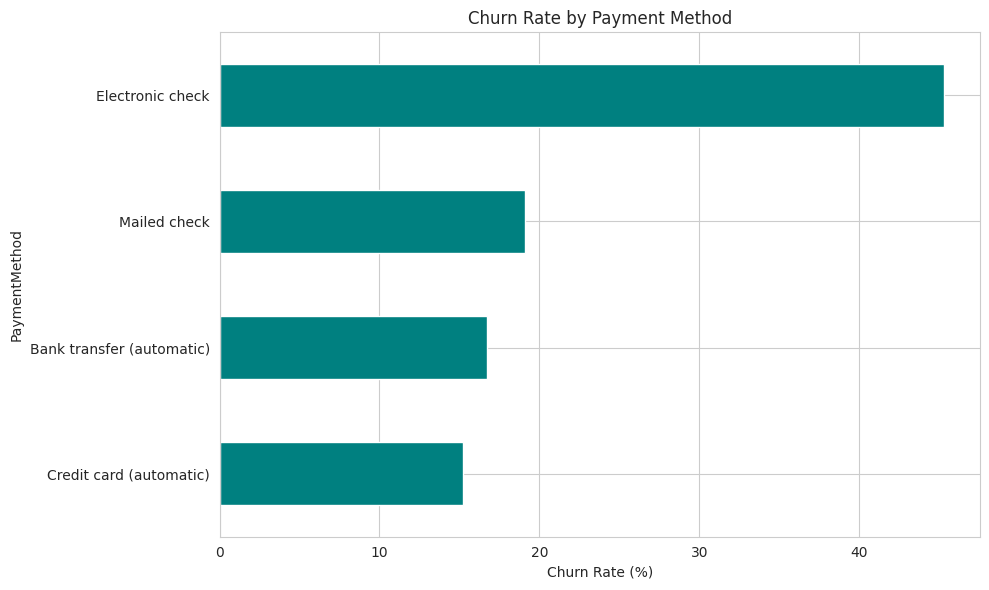

In [87]:
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
plt.figure(figsize=(10, 6))
payment_churn['Yes'].sort_values().plot(kind='barh', color='teal')
plt.title('Churn Rate by Payment Method') 
plt.xlabel('Churn Rate (%)') 
plt.tight_layout() 
plt.show() 

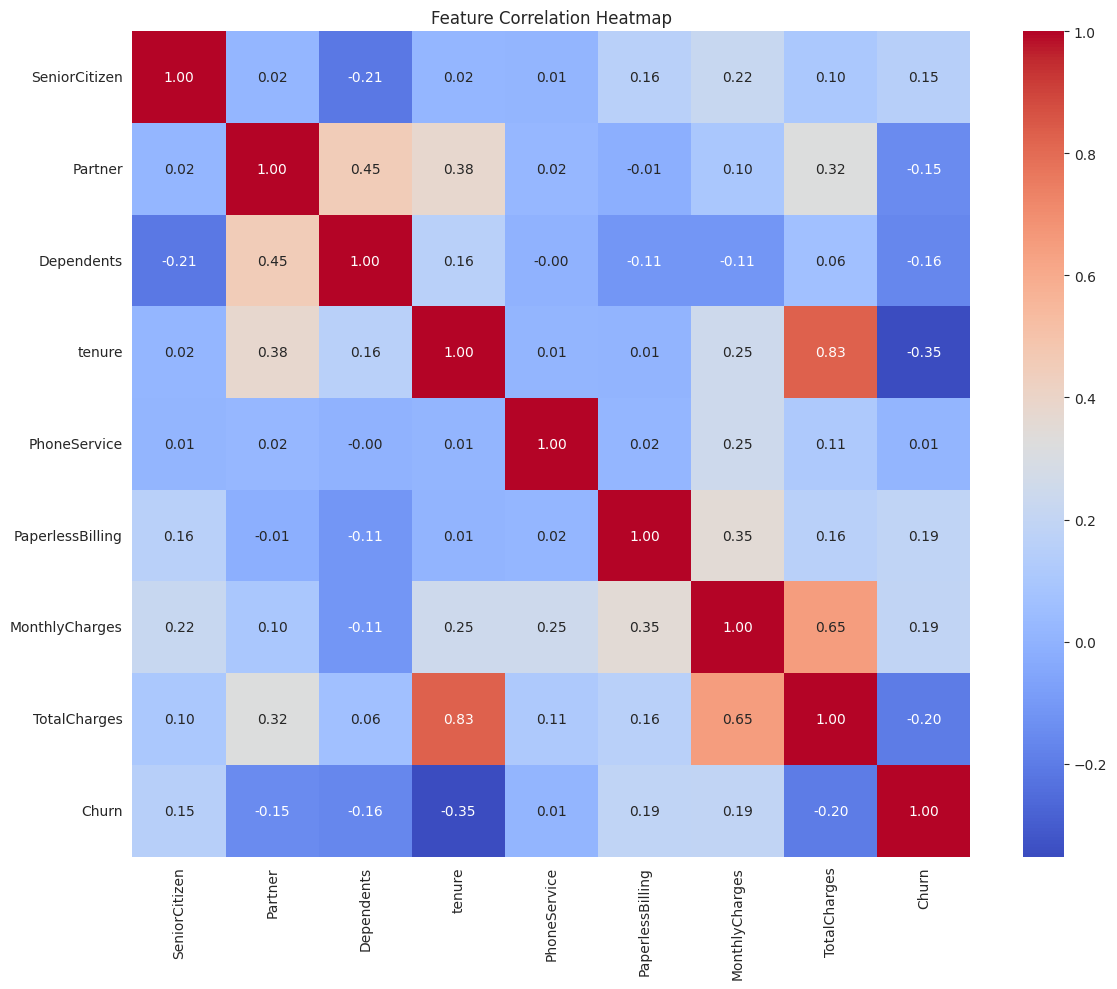

In [88]:
# Prepare numeric data
df_numeric = df.copy()
binary_cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in binary_cols:
    if col in df_numeric.columns:
        df_numeric[col] = df_numeric[col].map({'Yes': 1, 'No': 0})

# Select numeric features AFTER the loop finishes
numeric_features = df_numeric.select_dtypes(include=[np.number])

# Correlation heatmap (Outside the loop)
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_features.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# 📊 Task 3.1: Insights Summary & Key Findings

> **Overview:** Summary of high-risk customer profiles, key operational patterns, and strategic questions for subsequent modeling phases based on the Telco Customer Churn EDA.

---

### 🔴 1. High-Risk Customer Profile

Analysis reveals that customers with the following traits exhibit the **highest probability of churning**:

* **Contract Type:** Customers on **Month-to-month contracts** are at significantly higher risk than those on 1-year or 2-year commitments.
* **Tenure:** **New customers** within their initial months (low tenure, e.g., 0–12 months) show the highest rate of attrition.
* **Monthly Charges:** Customers with **higher MonthlyCharges** (typically $70–$110+) are far more likely to churn than low-cost plan subscribers.
* **Services Selected:**
  * **Fiber Optic Users:** Noticeably higher churn rates compared to DSL subscribers.
  * **Lack of Add-ons:** Customers **without value-added security services** (`OnlineSecurity`, `TechSupport`, or `DeviceProtection`) are substantially more prone to churning.
* **Payment Method:** Customers paying via **Electronic Check** churn at a much higher rate compared to automated methods (Bank Transfer or Credit Card).

---

### 📈 2. Observed Key Patterns & Relationships

| Pattern Area | Key Finding / Observation |
| :--- | :--- |
| **Ecosystem Anchor** | Customers adopting extra security/support services (`TechSupport`, `OnlineSecurity`) show high retention, indicating bundling acts as a churn barrier. |
| **Contract Stability** | Long-term contracts lock in customer loyalty, whereas month-to-month plans enable rapid exits for dissatisfied users. |
| **Fiber Optic Sensitivity** | Fiber optic services bring higher monthly bills; elevated churn suggests price sensitivity or potential service satisfaction issues. |
| **Target Imbalance** | Overall churn is **~26.5%** (1,869 churned vs. 5,174 retained), requiring class-imbalance handling in future ML models. |

---

### ❓ 3. Questions & Focus Areas for Next Week

1. **Multivariate Impact:** How do `MonthlyCharges` and `Tenure` interact combined to influence churn? *(e.g., Are high monthly charges only risky for newer customers?)*
2. **Feature Importance:** Which specific features deliver the strongest predictive power when training machine learning classification models?
3. **Fiber Optic Root Cause:** Is higher churn among Fiber Optic users strictly driven by price, or is there an underlying service quality issue?
4. **Retention Threshold:** What specific tenure or contract length marks the tipping point where customer churn stabilizes?